<a href="https://colab.research.google.com/github/ydchen17/ColabArchive/blob/main/Twitter_Sentimental_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset description

In [1]:
# we include 1 dataset downloaded from data.world
# Dataset: NASDAQ-100 companies twitter (79 days, from 28 Mar 2016 to 15 Jun 2016)
#     ref: http://www.followthehashtag.com/datasets/nasdaq-100-companies-free-twitter-dataset/
#     the full list of NASDAQ-100 can be found at: https://www.nasdaq.com/market-activity/quotes/nasdaq-ndx-index

# we tried to obtain data from twink, but the package seems not to work anymore
# we also tried to use tweepy, which no longer supports to search twitter since certain time
# A few examples of the attempts will be later uploaded to GitHub

# Zip file batch processing with Bash

In [2]:
# load Google Drive
# the link to my drive is https://drive.google.com/drive/folders/1azP6UOnBhqUBQurhKHNjioycucU0uYLG?usp=sharing
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


This is a bash script to save Apple twitter data. Do NOT run this cell for a second time and without necessary modification

pipeline: 
 1. jump to the working directory 
 2. unzip kike-170k-apple-tweets.zip

In [3]:
# %%bash
# cd /content/drive/MyDrive/DeepLearningProject_StockPrice
# unzip kike-170k-apple-tweets.zip

This is a bash script to process NASDAQ-100 twitter data. Do NOT run this cell for a second time and without necessary modification

pipeline: 
 1. jump to the working directory 
 2. create a folder named NASDAQ_100_Twitter_Archive
 3. unzip all zip files to the folder NASDAQ_100_Twitter_Archive
 4. jump to the folder
 5. find all zip files in the folder and unzip them to seperate folders
 6. create a folder named compressed
 7. move all zip files into the folder compressed as an archive


In [4]:
# %%bash
# cd /content/drive/MyDrive/DeepLearningProject_StockPrice
# mkdir NASDAQ_100_Twitter_Archive
# unzip NASDAQ_100_Twitter_Archive-A-to-F.zip -d NASDAQ_100_Twitter_Archive
# unzip NASDAQ_100_Twitter_Archive-F-to-X.zip -d NASDAQ_100_Twitter_Archive
# cd NASDAQ_100_Twitter_Archive
# find . -name '*.zip' -exec sh -c 'unzip -d "${1%.*}" "$1"' _ {} \;
# mkdir compressed
# find . -name '*.zip' -exec mv {} compressed \;

# Sentimental Analysis

In [5]:
# load the aapl twitter dataset
import pandas as pd
aapl_twitter = pd.read_excel("/content/drive/MyDrive/DeepLearningProject_StockPrice/NASDAQ_100_Twitter_Archive/aapl_2016_06_15_14_30_09.xlsx/export_dashboard_aapl_2016_06_15_14_30_09.xlsx", "Stream")
aapl_twitter_simp = aapl_twitter[["Date", "Hour", "Tweet content"]]

In [6]:
# data type?
aapl_twitter_simp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166631 entries, 0 to 166630
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Date           166631 non-null  object
 1   Hour           166631 non-null  object
 2   Tweet content  166631 non-null  object
dtypes: object(3)
memory usage: 3.8+ MB


In [7]:
# no missing data!
aapl_twitter_simp.isnull().sum()

Date             0
Hour             0
Tweet content    0
dtype: int64

In [8]:
# have a look at our data
aapl_twitter_simp.head()

,Date,Hour,Tweet content
0,2016-06-15,12:23,RT @kirillklip: Race for #renewable #energy #t...
1,2016-06-15,12:21,#APPLE TRIES to Limit #Google Incursions Onto ...
2,2016-06-15,12:21,#APPLE TRIES to Limit #Google Incursions Onto ...
3,2016-06-15,12:20,What calls do I sell on $twtr\n\n$spy $aapl $g...
4,2016-06-15,12:19,Good for $AAPL pay? https://t.co/6EuitFi8Au


## Data cleaning

In [9]:
# cleaning tweet content
%%capture
import re
def remove_pattern(input_txt, pattern):
    r = re.findall(pattern, input_txt)
    for i in r:
        input_txt = re.sub(i, '', input_txt)
    return input_txt

def remove_dollar_sign(input_txt):
    r = re.findall("\$[\w]*", input_txt)
    for i in r:
      i = i[1:]
      input_txt = re.sub("\$"+i, '', input_txt)
    return input_txt 

def remove_urls (vTEXT):
    vTEXT = re.sub(r'(https|http)?:\/\/(\w|\.|\/|\?|\=|\&|\%)*\b', '', vTEXT, flags=re.MULTILINE)
    return(vTEXT)

import numpy as np
!pip install emoji
import emoji

aapl_twitter_simp['tidy_text'] = aapl_twitter_simp['Tweet content']

# make single line
aapl_twitter_simp['tidy_text'] = aapl_twitter_simp['tidy_text'].apply(lambda x: ' '.join([w for w in x.split() if len(w)>1]))

# replace emoji
# see also: https://stackoverflow.com/questions/57580288/how-to-replace-emoji-to-word-in-a-text
aapl_twitter_simp['tidy_text'] = aapl_twitter_simp['tidy_text'].apply(lambda x: emoji.demojize(x))

# remove url
aapl_twitter_simp['tidy_text'] = aapl_twitter_simp['tidy_text'].apply(lambda x: remove_urls(x))

# remove at tag
aapl_twitter_simp['tidy_text'] = np.vectorize(remove_pattern)(aapl_twitter_simp['tidy_text'], "@[\w]*")

# I forgot to implement this but run the rest of the cells in the final run. It is better to do so, 
# though the results may differ a bit. 
aapl_twitter_simp['tidy_text'] = np.vectorize(remove_pattern)(aapl_twitter_simp['tidy_text'], "RT :")

# remove hashtag
aapl_twitter_simp['tidy_text'] = np.vectorize(remove_pattern)(aapl_twitter_simp['tidy_text'], "#[\w]*")

# remove dollar signs
aapl_twitter_simp['tidy_text'] = aapl_twitter_simp['tidy_text'].apply(lambda x: remove_dollar_sign(x))

In [10]:
# seems there is still things to clean... See Row 8
aapl_twitter_simp[["Date","tidy_text"]][:10]

,Date,tidy_text
0,2016-06-15,RT : Race for charges market …
1,2016-06-15,TRIES to Limit Incursions Onto Its Devices
2,2016-06-15,TRIES to Limit Incursions Onto Its Devices
3,2016-06-15,What calls do sell on
4,2016-06-15,Good for pay?
5,2016-06-15,Apple may again see super cycle akin to the iP...
6,2016-06-15,Time to talk iPhone 8: Apple ‘super cycle’ exp...
7,2016-06-15,Where will pin on Friday's OPEX?
8,2016-06-15,
9,2016-06-15,RT : vs : Reasons Not to Wait for ’s 2016 iPh...


In [11]:
# convert blank space string to NA
aapl_twitter_simp["tidy_text"] = aapl_twitter_simp["tidy_text"].replace(r'^\s*$', np.NaN, regex=True)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [12]:
# drop NA rows
aapl_twitter_simp = aapl_twitter_simp.dropna()
aapl_twitter_simp.shape

(165488, 4)

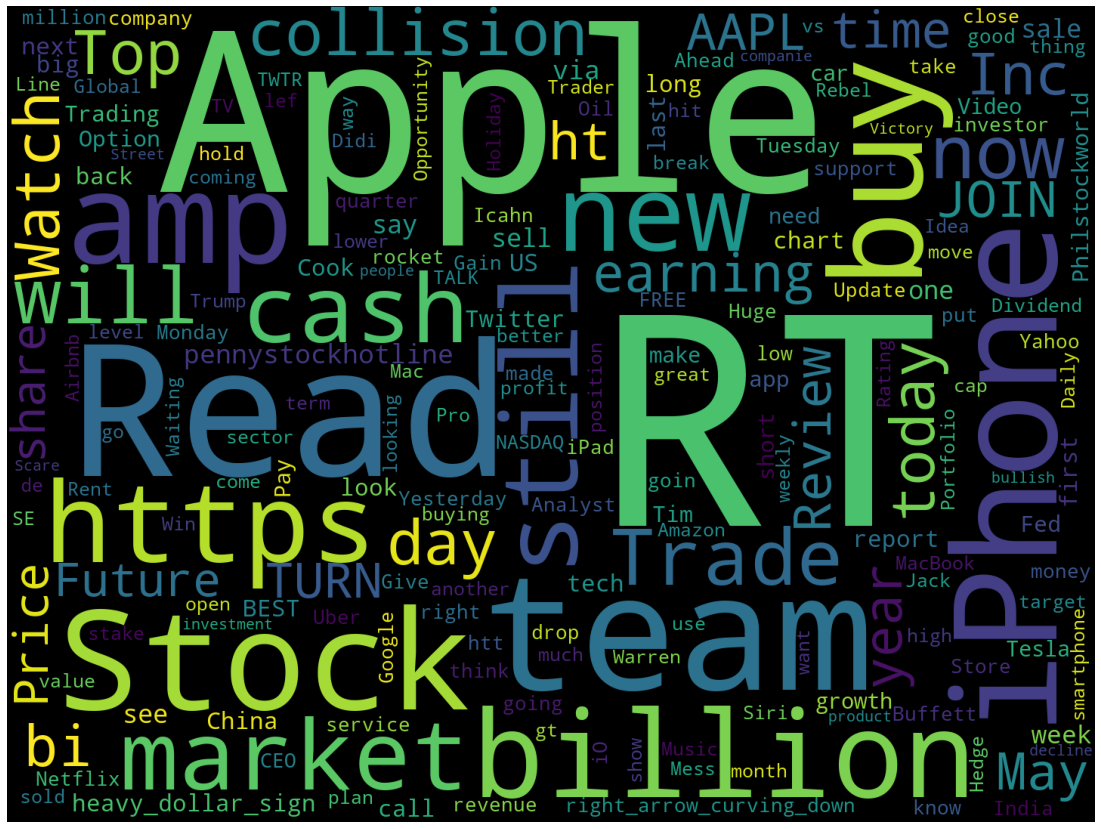

In [15]:
# finally, we can visualise the tweet with a word cloud to get an overview
import matplotlib.pyplot as plt
from wordcloud import WordCloud
def wc_plot(df):
  cloud = WordCloud(width=1440, height=1080, collocations=False).generate(str(df.tolist()))
  plt.figure(figsize=(20, 15))
  plt.imshow(cloud)
  plt.axis('off')

wc_plot(aapl_twitter_simp.tidy_text)

## Valence Aware Dictionary for Sentiment Reasoning (VADER) based sentimental classification

VADER is actually a classifier based on vocubulary. You can read [here](https://medium.com/@piocalderon/vader-sentiment-analysis-explained-f1c4f9101cd9) for more detail. Simply put, VADER uses dictionaries showing the emotion of different words, which is rated by human raters from Amazon Mechanical Turk. Punctuation, capitalisation, degree modification, polarity shift due to conjunctions, catching polarity negation are also taken into consideration when rating a sentence with VADER.

In [16]:
def sentiment_class(score):
    """
    Labels each tweet based on its sentiment score
    """
    if score > 0:
        score = "Positive"
    elif score < 0:
        score ='Negative'
    else:
        score = 'Neutral'
    return score

In [17]:
%%capture
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

# Instantiating the sentiment analyzer
sid = SentimentIntensityAnalyzer()
# Grabbing the sentiment scores and assigning them to a new column
aapl_twitter_simp['VADER_sentiment'] = [sid.polarity_scores(aapl_twitter_simp['tidy_text'].iloc[i])['compound'] for i in range(len(aapl_twitter_simp['tidy_text']))]
# Labeling the tweets in a new column
aapl_twitter_simp['VADER_feel'] = aapl_twitter_simp.VADER_sentiment.apply(sentiment_class)

In [18]:
# let's see how accurate this might be.
aapl_twitter_simp[["Date", "tidy_text", "VADER_sentiment", "VADER_feel"]].head()

,Date,tidy_text,VADER_sentiment,VADER_feel
0,2016-06-15,RT : Race for charges market …,-0.2732,Negative
1,2016-06-15,TRIES to Limit Incursions Onto Its Devices,0.0000,Neutral
2,2016-06-15,TRIES to Limit Incursions Onto Its Devices,0.0000,Neutral
3,2016-06-15,What calls do sell on,0.0000,Neutral
4,2016-06-15,Good for pay?,0.3612,Positive


In [19]:
aapl_twitter_simp["VADER_feel"].value_counts()

Neutral     79158
Positive    56321
Negative    30009
Name: VADER_feel, dtype: int64

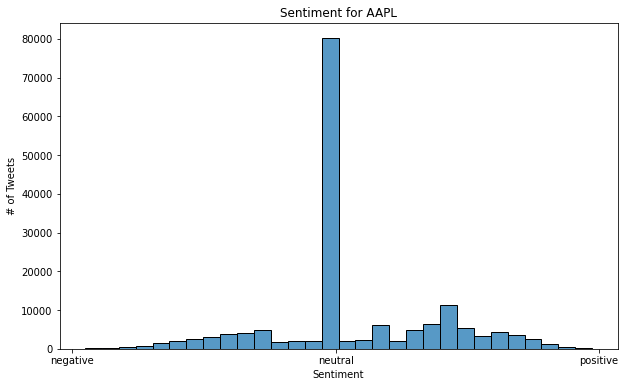

In [32]:
import seaborn
fig, ax = plt.subplots(figsize=(10,6))

# Plotting the sentiment scores
# don't use displot as it will plot a seperate plot.

seaborn.histplot(aapl_twitter_simp['VADER_sentiment'], bins=30)
plt.title(f"Sentiment for AAPL")
ax.set_xticks([-1,0,1])
ax.set_xticklabels(['negative', 'neutral', 'positive'])
plt.xlabel("Sentiment")
plt.ylabel("# of Tweets")
plt.show()

### Visualisation of Positve Sentiments

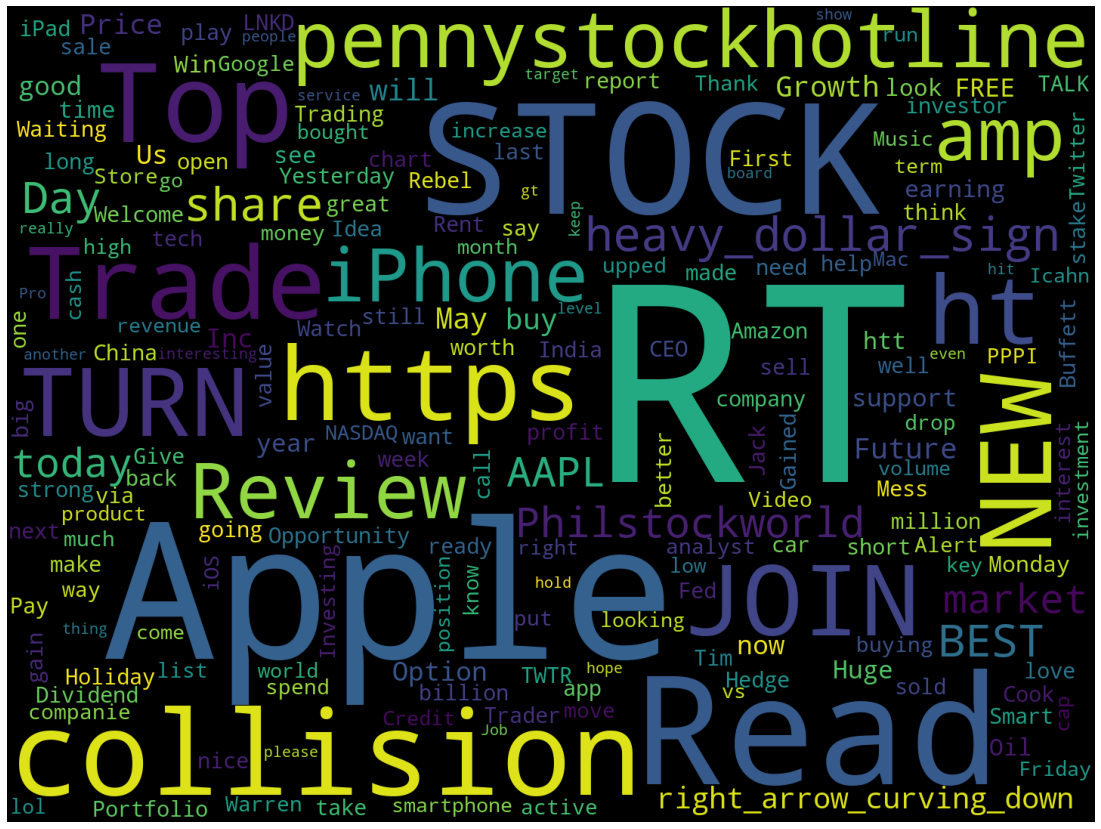

In [21]:
# let's visualise positive, neutral, negative sentiment suggested by VADER with word cloud.
wc_plot(aapl_twitter_simp[aapl_twitter_simp["VADER_feel"] == "Positive"].tidy_text)

### Visualisation of Neutral Sentiments

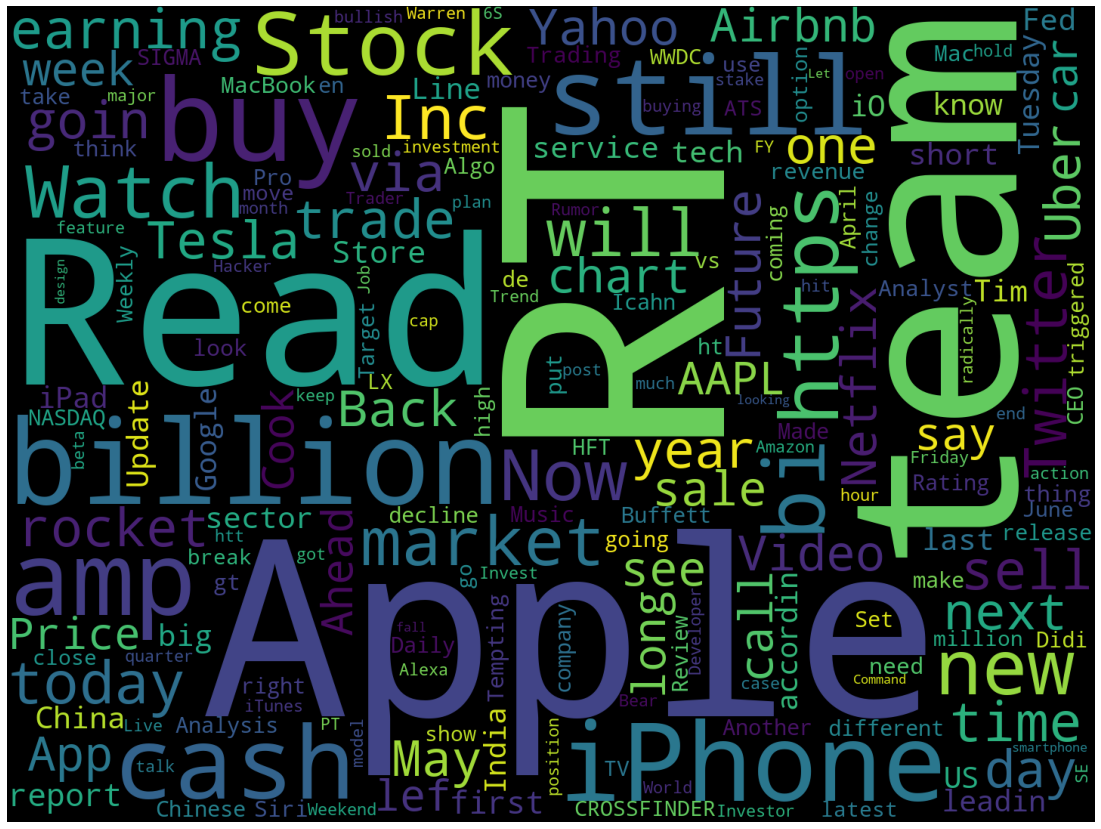

In [22]:
wc_plot(aapl_twitter_simp[aapl_twitter_simp["VADER_feel"] == "Neutral"].tidy_text)

### Visualisation of Negative Sentiments

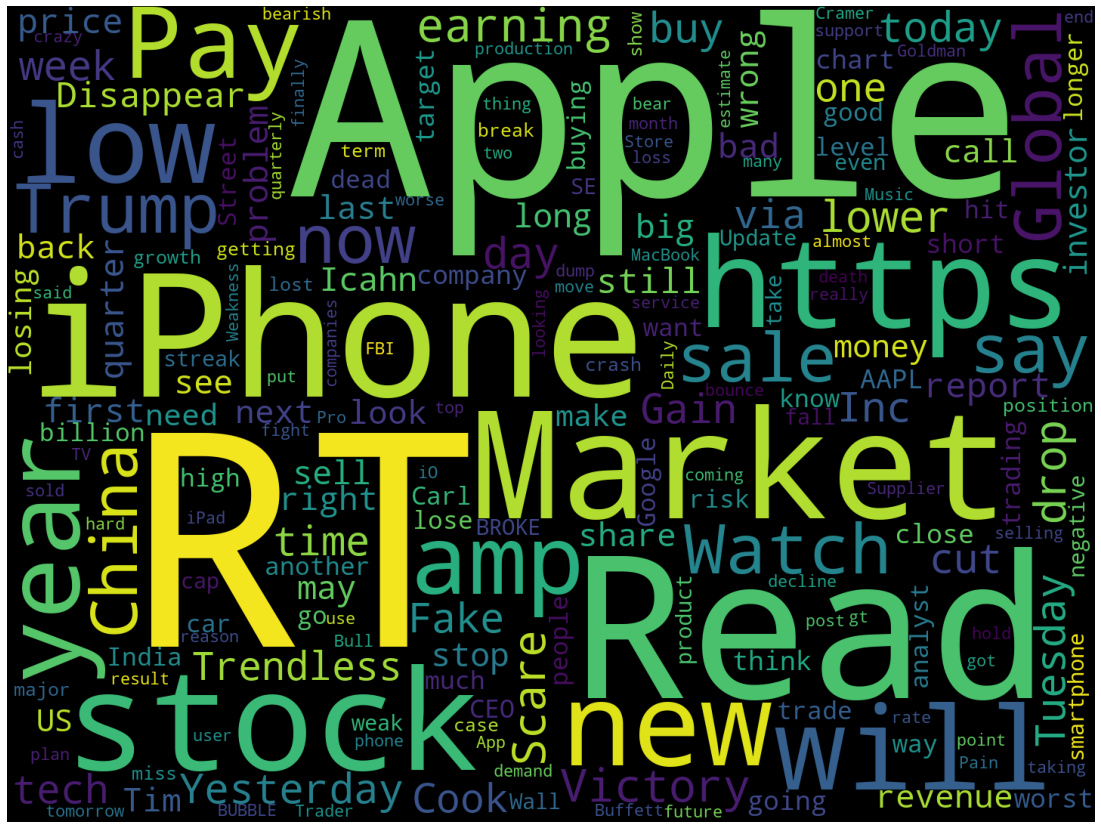

In [23]:
wc_plot(aapl_twitter_simp[aapl_twitter_simp["VADER_feel"] == "Negative"].tidy_text)

## DistilBERT based sentimenal classification
Here we use the [flair](https://github.com/flairNLP/flair) package to make sentimental analysis, which is based on [the DistilBERT model](https://arxiv.org/abs/1910.01108), a state-of-the-art natural language processing (NLP) model to date. Comparing to VADER which is based on lexicon, DistilBERT and BERT are both deep learning models, which may capture more information through training. Here pre-trained models for English text classification is used.

In [24]:
# load the distilBERT model for sentimental analysis
%%capture
!pip install flair
import flair
sentiment_model = flair.models.TextClassifier.load('en-sentiment')

In [25]:
# uncomment below to see model architecture
# sentiment_model

In [27]:
# append new columns to our dataset
# we will append probability and sentiment preds later
probs = []
sentiments = []

for tweet in aapl_twitter_simp["tidy_text"].to_list():
    # make prediction
    sentence = flair.data.Sentence(tweet)
    sentiment_model.predict(sentence)
    # extract sentiment prediction
    try:
      probs.append(sentence.labels[0].score)  # numerical score 0-1
      sentiments.append(sentence.labels[0].value)  # 'POSITIVE' or 'NEGATIVE'
    except:
      probs.append(np.nan)
      sentiments.append(np.nan)
      print(tweet)

# add probability and sentiment predictions to tweets dataframe
aapl_twitter_simp['DistilBERT_score'] = probs
aapl_twitter_simp['DistilBERT_feel'] = sentiments

​    


In [28]:
# save the sentimental data to Google Drive
aapl_twitter_simp.to_csv("/content/drive/MyDrive/DeepLearningProject_StockPrice/ALL_sent_score.csv")
aapl_twitter_simp[["Date", "tidy_text", "VADER_sentiment", "VADER_feel"]].to_csv("/content/drive/MyDrive/DeepLearningProject_StockPrice/VADER_score.csv")
aapl_twitter_simp[["Date", "tidy_text", "DistilBERT_score", "DistilBERT_feel"]].to_csv("/content/drive/MyDrive/DeepLearningProject_StockPrice/BERT_score.csv")

In [29]:
# what is different from DistilBERT based classifier is that it makes a binary rather than a 3-class classification as shown below
aapl_twitter_simp['DistilBERT_feel'].value_counts()

NEGATIVE    95852
POSITIVE    69635
Name: DistilBERT_feel, dtype: int64

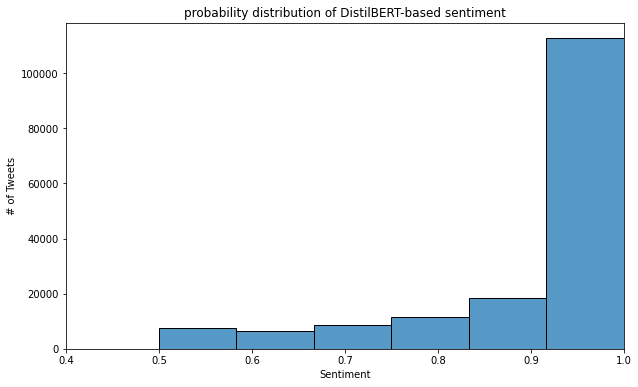

In [30]:
# also the sentiment score here is actually probability, so only those > 0.5 are considered, while most of the identified sentiment is larger than 0.9.

fig, ax = plt.subplots(figsize=(10,6))

# Plotting the sentiment scores
seaborn.histplot(aapl_twitter_simp['DistilBERT_score'], bins=6)
plt.title(f"probability distribution of DistilBERT-based sentiment")
ax.set_xlim([0.4,1])
plt.xlabel("Sentiment")
plt.ylabel("# of Tweets")
plt.show()

(-0.5, 1439.5, 1079.5, -0.5)

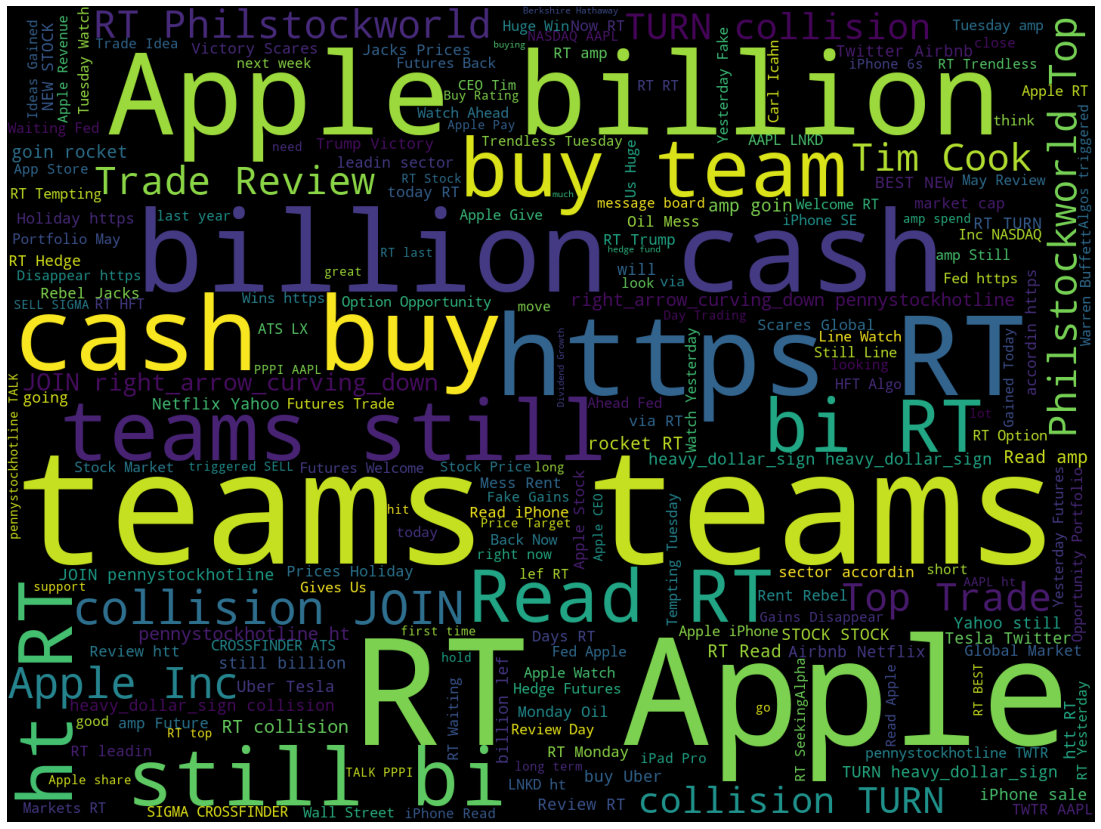

In [31]:
from wordcloud import WordCloud
aapl_twitter_simp

cloud = WordCloud(width=1440, height=1080).generate(str(aapl_twitter_simp.tidy_text.tolist()))
plt.figure(figsize=(20, 15))
plt.imshow(cloud)
plt.axis('off')

### Visualisation of Negative Sentiments

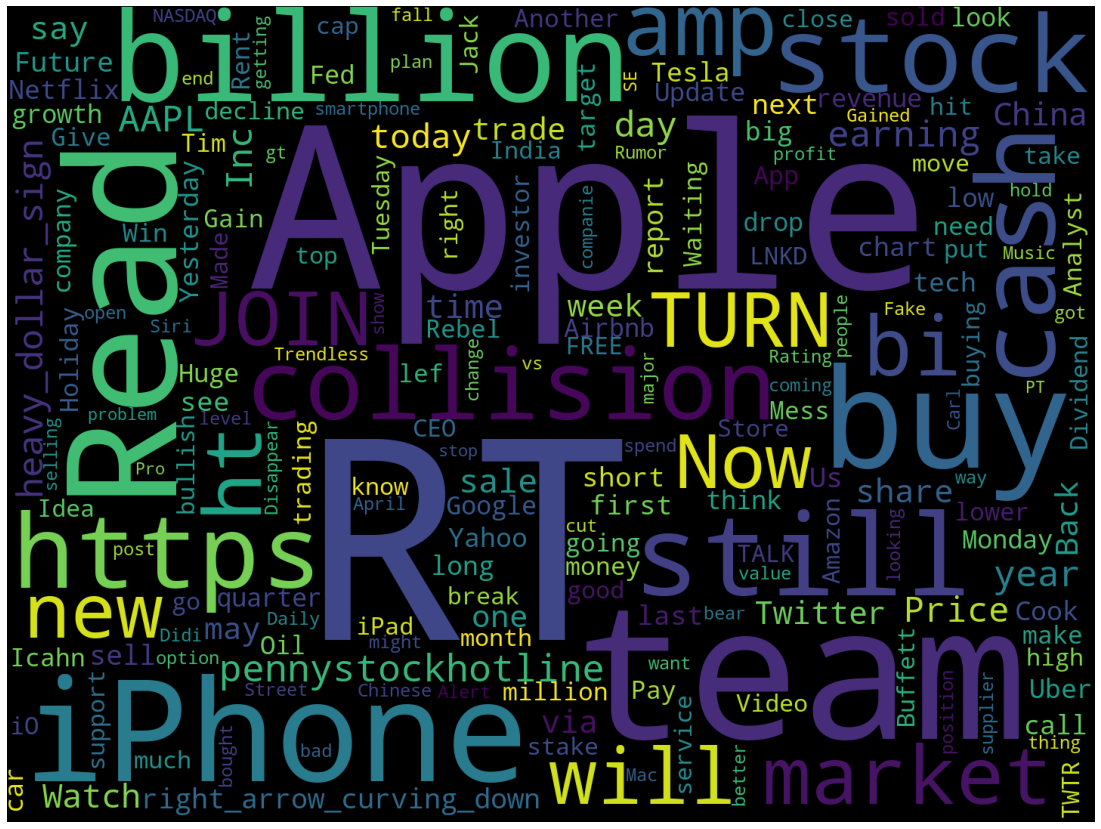

In [33]:
wc_plot(aapl_twitter_simp[aapl_twitter_simp["DistilBERT_feel"] == "NEGATIVE"].tidy_text)

### Visualisation of Positive Sentiments

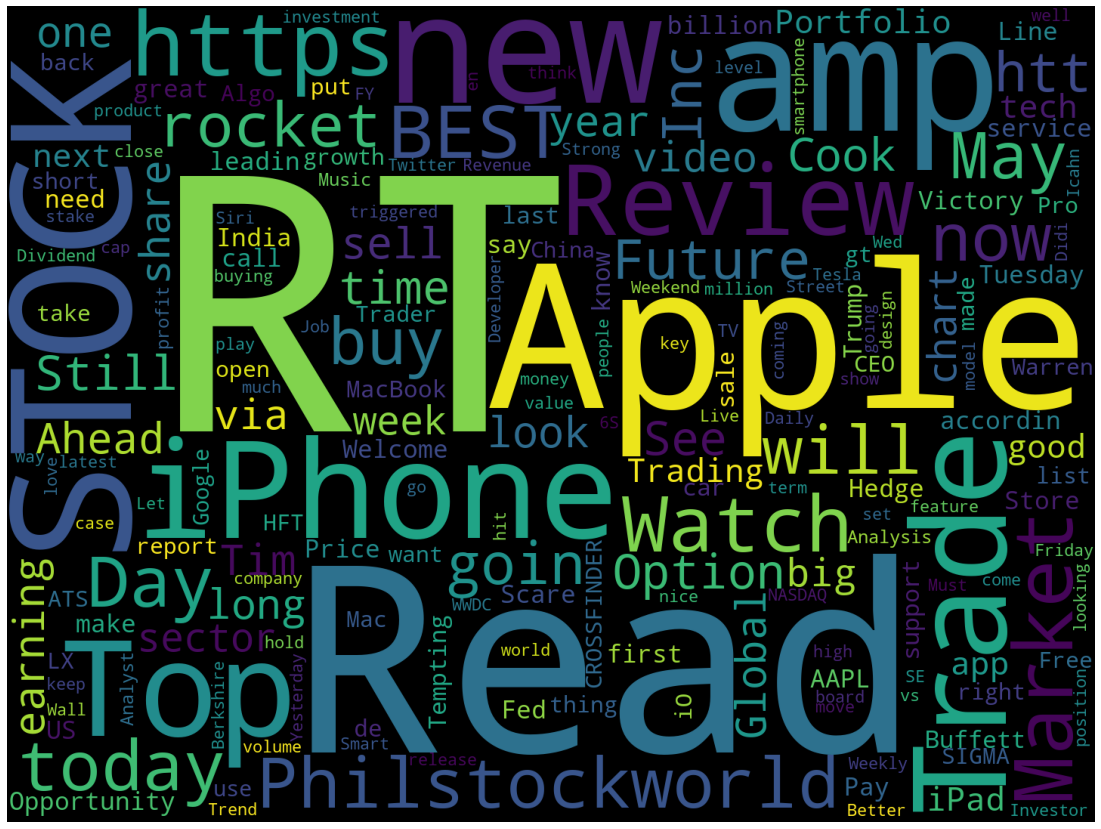

In [34]:
wc_plot(aapl_twitter_simp[aapl_twitter_simp["DistilBERT_feel"] == "POSITIVE"].tidy_text)

# Calculate Daily Sentiments

## VADER

In [35]:
VADER_scores = pd.read_csv("/content/drive/MyDrive/DeepLearningProject_StockPrice/VADER_score.csv")

# construct features based on VADER sentimental analysis
daily_VADER_scores = pd.DataFrame()
daily_VADER_scores["avg_VADER_sentiment"] = VADER_scores.VADER_sentiment.groupby(VADER_scores.Date).mean()
daily_VADER_scores["sum_VADER_sentiment"] = VADER_scores.VADER_sentiment.groupby(VADER_scores.Date).sum()
VADER_scores_counts = VADER_scores.groupby(['Date', 'VADER_feel'], as_index=False).size()
daily_VADER_scores["Negative"] = VADER_scores_counts[VADER_scores_counts.VADER_feel=="Negative"]["size"].tolist()
daily_VADER_scores["Positive"] = VADER_scores_counts[VADER_scores_counts.VADER_feel=="Positive"]["size"].tolist()
daily_VADER_scores["Neutral"] = VADER_scores_counts[VADER_scores_counts.VADER_feel=="Neutral"]["size"].tolist()
daily_VADER_scores["Total"] = daily_VADER_scores["Neutral"] + daily_VADER_scores["Positive"] + daily_VADER_scores["Negative"]
daily_VADER_scores["NegativeRate"] = daily_VADER_scores["Negative"]/daily_VADER_scores["Total"]
daily_VADER_scores["PositiveRate"] = daily_VADER_scores["Positive"]/daily_VADER_scores["Total"]
daily_VADER_scores["NeutralRate"] = daily_VADER_scores["Neutral"]/daily_VADER_scores["Total"]
daily_VADER_scores.index = pd.to_datetime(daily_VADER_scores.index)
daily_VADER_scores.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 69 entries, 2016-04-02 to 2016-06-15
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   avg_VADER_sentiment  69 non-null     float64
 1   sum_VADER_sentiment  69 non-null     float64
 2   Negative             69 non-null     int64  
 3   Positive             69 non-null     int64  
 4   Neutral              69 non-null     int64  
 5   Total                69 non-null     int64  
 6   NegativeRate         69 non-null     float64
 7   PositiveRate         69 non-null     float64
 8   NeutralRate          69 non-null     float64
dtypes: float64(5), int64(4)
memory usage: 5.4 KB


In [36]:
daily_VADER_scores.to_csv("/content/drive/MyDrive/DeepLearningProject_StockPrice/daily_VADER_scores.csv")
daily_VADER_scores.head()

,avg_VADER_sentiment,sum_VADER_sentiment,Negative,Positive,Neutral,Total,NegativeRate,PositiveRate,NeutralRate
Date,,,,,,,,,
2016-04-02,0.122949,35.6553,18,89,183,290,0.062069,0.306897,0.631034
2016-04-03,0.068940,56.8066,118,252,454,824,0.143204,0.305825,0.550971
2016-04-04,0.077522,209.3870,248,667,1786,2701,0.091818,0.246946,0.661237
2016-04-05,0.076634,97.5546,211,412,650,1273,0.165750,0.323645,0.510605
2016-04-06,0.124466,171.2649,197,548,631,1376,0.143169,0.398256,0.458576


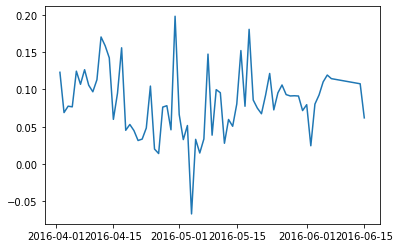

In [37]:
import matplotlib.pyplot as plt
# visualise the sentimental changes
plt.plot(daily_VADER_scores["avg_VADER_sentiment"])

## DistilBERT

In [38]:
# load our previously saved dataset
DistilBERT_scores = pd.read_csv("/content/drive/MyDrive/DeepLearningProject_StockPrice/BERT_score.csv")
DistilBERT_scores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165488 entries, 0 to 165487
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        165488 non-null  int64  
 1   Date              165488 non-null  object 
 2   tidy_text         165488 non-null  object 
 3   DistilBERT_score  165487 non-null  float64
 4   DistilBERT_feel   165487 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 6.3+ MB


In [39]:
DistilBERT_scores[["Date", "DistilBERT_score", "DistilBERT_feel"]]

,Date,DistilBERT_score,DistilBERT_feel
0,2016-06-15,0.516011,NEGATIVE
1,2016-06-15,0.990406,NEGATIVE
2,2016-06-15,0.990406,NEGATIVE
3,2016-06-15,0.596341,NEGATIVE
4,2016-06-15,0.974373,NEGATIVE
...,...,...,...
165483,2016-04-02,0.523799,NEGATIVE
165484,2016-04-02,0.897255,NEGATIVE
165485,2016-04-02,0.897255,NEGATIVE
165486,2016-04-02,0.954626,POSITIVE


In [40]:
# since the probability data do not indicate directionality, we construct a new feature based on that, as described below:
def direction(a, b):
  if b=="NEGATIVE":
    return -a
  else:
    return a
DistilBERT_scores["DistilBERT_sentiment"] = DistilBERT_scores.apply(lambda row: direction(row[3], row[4]), axis = 1)

daily_DistilBERT_scores = pd.DataFrame()
daily_DistilBERT_scores["avg_DistilBERT_sentiment"] = DistilBERT_scores.DistilBERT_sentiment.groupby(DistilBERT_scores.Date).mean()
daily_DistilBERT_scores["sum_DistilBERT_sentiment"] = DistilBERT_scores.DistilBERT_sentiment.groupby(DistilBERT_scores.Date).sum()
DistilBERT_scores_counts = DistilBERT_scores.groupby(['Date', 'DistilBERT_feel'], as_index=False).size()
daily_DistilBERT_scores["Negative"] = DistilBERT_scores_counts[DistilBERT_scores_counts.DistilBERT_feel=="NEGATIVE"]["size"].tolist()
daily_DistilBERT_scores["Positive"] = DistilBERT_scores_counts[DistilBERT_scores_counts.DistilBERT_feel=="POSITIVE"]["size"].tolist()
daily_DistilBERT_scores["Total"] = daily_DistilBERT_scores["Positive"] + daily_DistilBERT_scores["Negative"]
daily_DistilBERT_scores["NegativeRate"] = daily_DistilBERT_scores["Negative"]/daily_DistilBERT_scores["Total"]
daily_DistilBERT_scores["PositiveRate"] = daily_DistilBERT_scores["Positive"]/daily_DistilBERT_scores["Total"]
daily_DistilBERT_scores.index = pd.to_datetime(daily_DistilBERT_scores.index)
daily_DistilBERT_scores.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 69 entries, 2016-04-02 to 2016-06-15
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   avg_DistilBERT_sentiment  69 non-null     float64
 1   sum_DistilBERT_sentiment  69 non-null     float64
 2   Negative                  69 non-null     int64  
 3   Positive                  69 non-null     int64  
 4   Total                     69 non-null     int64  
 5   NegativeRate              69 non-null     float64
 6   PositiveRate              69 non-null     float64
dtypes: float64(4), int64(3)
memory usage: 4.3 KB


In [41]:
daily_DistilBERT_scores.to_csv("/content/drive/MyDrive/DeepLearningProject_StockPrice/daily_DistilBERT_scores.csv")
daily_DistilBERT_scores.head()

,avg_DistilBERT_sentiment,sum_DistilBERT_sentiment,Negative,Positive,Total,NegativeRate,PositiveRate
Date,,,,,,,
2016-04-02,0.313142,90.811308,83,207,290,0.286207,0.713793
2016-04-03,0.166638,137.309550,325,499,824,0.394417,0.605583
2016-04-04,0.329520,890.032722,892,1809,2701,0.330248,0.669752
2016-04-05,-0.061995,-78.920067,676,597,1273,0.531029,0.468971
2016-04-06,-0.016196,-22.285574,698,678,1376,0.507267,0.492733


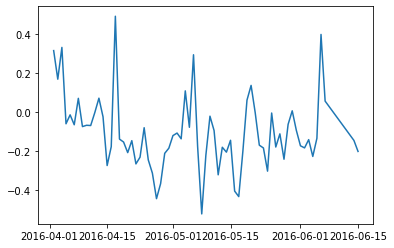

In [42]:
# visualise the sentimental changes
plt.plot(daily_DistilBERT_scores["avg_DistilBERT_sentiment"])

# Acquiring Apple stock price data

In [43]:
import requests
# Let's make a standard input as below
function = "TIME_SERIES_DAILY"
symbol="AAPL"
outputsize="full"
apikey="T6VX725RGZZJFF8P"
# Then the web link should be as below:
fulllink = "https://www.alphavantage.co/query?function="+function+"&symbol="+symbol+"&outputsize="+outputsize+"&apikey="+apikey
res = requests.get(fulllink)
res_json = res.json()
res

# change data type
all = pd.DataFrame.from_dict(res_json['Time Series (Daily)']).T
all.index = pd.to_datetime(all.index)
all = all.astype('float32')

# select the time period of our interest
all.index = pd.to_datetime(all.index)
df = all['2016-06-15' > all.index]
df = df['2016-04-01' < df.index]

# there is 51 trading day during the time
# df.describe()

In [44]:
# make class labels of price increase or decrease in the Apple stock price dataset
def change_category(open, close):
  if open - close < 0:
    return 1
  else:
    return 0
df["change_category"] = df.apply(lambda x: change_category(x[0], x[3]), axis = 1)

In [45]:
df.head()

,1. open,2. high,3. low,4. close,5. volume,change_category
2016-06-14,97.320000,98.474998,96.750000,97.459999,31931944.0,1
2016-06-13,98.690002,99.120003,97.099998,97.339996,38020496.0,0
2016-06-10,98.529999,99.345703,98.480003,98.830002,31712936.0,1
2016-06-09,98.500000,99.989998,98.459999,99.650002,26601354.0,1
2016-06-08,99.019997,99.559998,98.680000,98.940002,20848132.0,0


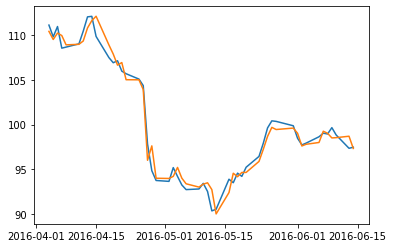

In [46]:
# below shows the trend of the stock price
plt.plot(df["4. close"])
plt.plot(df["1. open"])

# Merging emotional and trading datasets

In [47]:
df_merge_VADER = pd.concat([df, daily_VADER_scores], axis=1)
# let's assume that the stock price don't change in the non-trading day.
# this is because the event-driven sentiment changes on non-trading days also often affect trading days.
df_merge_VADER = df_merge_VADER.fillna(method='pad')
df_merge_VADER = df_merge_VADER.dropna()
df_merge_VADER

,1. open,2. high,3. low,4. close,5. volume,change_category,avg_VADER_sentiment,sum_VADER_sentiment,Negative,Positive,Neutral,Total,NegativeRate,PositiveRate,NeutralRate
2016-04-04,110.419998,112.190002,110.269997,111.120003,37356204.0,1.0,0.077522,209.3870,248.0,667.0,1786.0,2701.0,0.091818,0.246946,0.661237
2016-04-05,109.510002,110.730003,109.419998,109.809998,26578652.0,1.0,0.076634,97.5546,211.0,412.0,650.0,1273.0,0.165750,0.323645,0.510605
2016-04-06,110.230003,110.980003,109.199997,110.959999,26404076.0,1.0,0.124466,171.2649,197.0,548.0,631.0,1376.0,0.143169,0.398256,0.458576
2016-04-07,109.949997,110.419998,108.121002,108.540001,31801870.0,0.0,0.106842,213.4711,428.0,767.0,803.0,1998.0,0.214214,0.383884,0.401902
2016-04-08,108.910004,109.769997,108.169998,108.660004,23581740.0,0.0,0.126420,245.5068,326.0,720.0,896.0,1942.0,0.167868,0.370752,0.461380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-06-09,98.500000,99.989998,98.459999,99.650002,26601354.0,1.0,0.114442,42.5723,37.0,130.0,205.0,372.0,0.099462,0.349462,0.551075
2016-06-10,98.529999,99.345703,98.480003,98.830002,31712936.0,1.0,0.114442,42.5723,37.0,130.0,205.0,372.0,0.099462,0.349462,0.551075
2016-06-13,98.690002,99.120003,97.099998,97.339996,38020496.0,0.0,0.114442,42.5723,37.0,130.0,205.0,372.0,0.099462,0.349462,0.551075
2016-06-14,97.320000,98.474998,96.750000,97.459999,31931944.0,1.0,0.107572,34.9610,40.0,101.0,184.0,325.0,0.123077,0.310769,0.566154


In [48]:
daily_DistilBERT_scores.index

DatetimeIndex(['2016-04-02', '2016-04-03', '2016-04-04', '2016-04-05',
               '2016-04-06', '2016-04-07', '2016-04-08', '2016-04-09',
               '2016-04-10', '2016-04-11', '2016-04-12', '2016-04-13',
               '2016-04-14', '2016-04-15', '2016-04-16', '2016-04-17',
               '2016-04-18', '2016-04-19', '2016-04-20', '2016-04-21',
               '2016-04-22', '2016-04-23', '2016-04-24', '2016-04-25',
               '2016-04-26', '2016-04-27', '2016-04-28', '2016-04-29',
               '2016-04-30', '2016-05-01', '2016-05-02', '2016-05-03',
               '2016-05-04', '2016-05-05', '2016-05-06', '2016-05-07',
               '2016-05-08', '2016-05-09', '2016-05-10', '2016-05-11',
               '2016-05-12', '2016-05-13', '2016-05-14', '2016-05-15',
               '2016-05-16', '2016-05-17', '2016-05-18', '2016-05-19',
               '2016-05-20', '2016-05-21', '2016-05-22', '2016-05-23',
               '2016-05-24', '2016-05-25', '2016-05-26', '2016-05-27',
      

In [ ]:
# then we do similar things to the BERT dataset.
df_merge_DistilBERT = pd.concat([df, daily_DistilBERT_scores], axis=1)
# let's assume that the stock price don't change in the non-trading day.
df_merge_DistilBERT = df_merge_DistilBERT.fillna(method='pad')
df_merge_DistilBERT = df_merge_DistilBERT.dropna()
len(df_merge_DistilBERT.index)

In [50]:
df_merge_DistilBERT

,1. open,2. high,3. low,4. close,5. volume,change_category,avg_DistilBERT_sentiment,sum_DistilBERT_sentiment,Negative,Positive,Total,NegativeRate,PositiveRate
2016-04-04,110.419998,112.190002,110.269997,111.120003,37356204.0,1.0,0.329520,890.032722,892.0,1809.0,2701.0,0.330248,0.669752
2016-04-05,109.510002,110.730003,109.419998,109.809998,26578652.0,1.0,-0.061995,-78.920067,676.0,597.0,1273.0,0.531029,0.468971
2016-04-06,110.230003,110.980003,109.199997,110.959999,26404076.0,1.0,-0.016196,-22.285574,698.0,678.0,1376.0,0.507267,0.492733
2016-04-07,109.949997,110.419998,108.121002,108.540001,31801870.0,0.0,-0.066993,-133.852631,1054.0,944.0,1998.0,0.527528,0.472472
2016-04-08,108.910004,109.769997,108.169998,108.660004,23581740.0,0.0,0.068440,132.910980,890.0,1052.0,1942.0,0.458290,0.541710
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-06-09,98.500000,99.989998,98.459999,99.650002,26601354.0,1.0,0.054293,20.196930,176.0,196.0,372.0,0.473118,0.526882
2016-06-10,98.529999,99.345703,98.480003,98.830002,31712936.0,1.0,0.054293,20.196930,176.0,196.0,372.0,0.473118,0.526882
2016-06-13,98.690002,99.120003,97.099998,97.339996,38020496.0,0.0,0.054293,20.196930,176.0,196.0,372.0,0.473118,0.526882
2016-06-14,97.320000,98.474998,96.750000,97.459999,31931944.0,1.0,-0.147334,-47.883634,192.0,133.0,325.0,0.590769,0.409231


Thus, we construct two feature matrix here. The output should be the closing prices of the next trading day.

In [51]:
# create a y containing the closing price of the next date
begin = pd.Timestamp('2016-04-05')
end = pd.Timestamp('2016-06-16')
existing = df_merge_DistilBERT["4. close"].truncate(before=begin, after=end)

In [52]:
y = existing.append(all["4. close"].truncate('2016-06-16', '2016-06-16'))

# Data tranformation for training

In [55]:
y = pd.DataFrame(y)

In [56]:
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.preprocessing import MinMaxScaler  

# specify X, y
X_VADER = df_merge_VADER
X_DistilBERT = df_merge_DistilBERT

# data scaling with MinMaxScaler
scaler = MinMaxScaler()
X_VADER = scaler.fit_transform(X_VADER)
X_DistilBERT = scaler.fit_transform(X_DistilBERT)

y_scaler = MinMaxScaler()
y = y_scaler.fit_transform(y)

In [57]:
print((X_DistilBERT.shape, y.shape))

((71, 13), (71, 1))


In [58]:
print((X_VADER.shape, y.shape))

((71, 15), (71, 1))


# Build a LSTM model for time-series prediction

In [59]:
# this is just a typical LSTM.... not very surprising
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# training VADER-based model

In [60]:
# train/test split
X_VADER_train, X_VADER_test, y_train, y_test = train_test_split(X_VADER, y, test_size=0.3, random_state=42)

# The LSTM API from Keras needs to receive the features data as a vertical vector, 
# so that we need to reshape the X data in the form reshape((X_train.shape[0], X_train.shape[1], 1)).
X_VADER_train = X_VADER_train.reshape((X_VADER_train.shape[0], X_VADER_train.shape[1], 1))
X_VADER_test = X_VADER_test.reshape((X_VADER_test.shape[0], X_VADER_test.shape[1], 1))

# Build the LSTM model. 
# Define the LSTM RNN model.


def build_model(X_train_shape):
  model = Sequential()
  number_units = 9
  dropout_fraction = 0.2

  # Layer 1
  model.add(LSTM(
    units=number_units,
    return_sequences=True,
    input_shape=(X_train_shape[1], 1)))
  model.add(Dropout(dropout_fraction))

  # Layer 2
  # The return_sequences parameter needs to set to True every time we add a new LSTM layer, excluding the final layer.
  model.add(LSTM(units=number_units, return_sequences=True))
  model.add(Dropout(dropout_fraction))

  # Layer 3
  model.add(LSTM(units=number_units))
  model.add(Dropout(dropout_fraction))

  # Output layer
  model.add(Dense(1))

  model.compile(optimizer="adam", loss="mean_squared_error")
  print(model.summary())

  return model

In [61]:
model = build_model(X_VADER_train.shape)
model.fit(X_VADER_train, y_train, epochs=200, shuffle=False, batch_size=5, verbose=1)

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (None, 15, 9)             396       
_________________________________________________________________
dropout (Dropout)            (None, 15, 9)             0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 15, 9)             684       
_________________________________________________________________
dropout_1 (Dropout)          (None, 15, 9)             0         
_________________________________________________________________
lstm_2 (LSTM)                (None, 9)                 684       
_________________________________________________________________
dropout_2 (Dropout)          (None, 9)                 0         
_________________________________________________________________
dense (Dense)                (None, 1)                 1

In [62]:
# Evaluate the model for loss
model.evaluate(X_VADER_test, y_test)

1/1 [==============================] - 1s 1s/step - loss: 0.0034


0.003353305859491229

In [63]:
# Evaluating the model
predicted = model.predict(X_VADER_test)
from sklearn import metrics
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, predicted)))
print('R-squared :', metrics.r2_score(y_test, predicted))

Root Mean Squared Error: 0.05790775
R-squared : 0.964389808974111


In [64]:
# Recover the original prices instead of the scaled version
predicted_prices = y_scaler.inverse_transform(predicted)
real_prices = y_scaler.inverse_transform(y_test.reshape(-1, 1))

stocks = pd.DataFrame({
    "Real": real_prices.ravel(),
    "Predicted": predicted_prices.ravel()
}, index = df.index[-len(real_prices): ]) 
stocks.head()

,Real,Predicted
2016-05-03,97.819992,102.451698
2016-05-02,109.809998,110.802696
2016-04-29,97.900002,96.779305
2016-04-28,108.660011,108.298065
2016-04-27,100.349998,100.737724


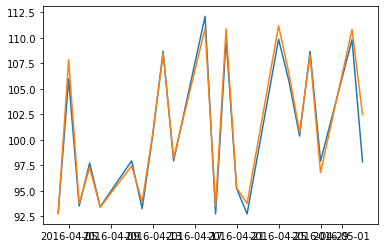

In [65]:
# sorry but we don't have time to transform this back to the normal unit. the accuracy looks good though.
plt.plot(stocks["Real"])
plt.plot(stocks["Predicted"])

# traininng DistilBERT based model

In [66]:
# train/test split
X_DistilBERT_train, X_DistilBERT_test, y_train, y_test = train_test_split(X_DistilBERT, y, test_size=0.3, random_state=42)
# reshape input data
X_DistilBERT_train = X_DistilBERT_train.reshape((X_DistilBERT_train.shape[0], X_DistilBERT_train.shape[1], 1))
X_DistilBERT_test = X_DistilBERT_test.reshape((X_DistilBERT_test.shape[0], X_DistilBERT_test.shape[1], 1))

In [69]:
model2 = build_model(X_DistilBERT_train.shape)
model2.fit(X_DistilBERT_train, y_train, epochs=200, shuffle=False, batch_size=5, verbose=1)

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_9 (LSTM)                (None, 13, 9)             396       
_________________________________________________________________
dropout_9 (Dropout)          (None, 13, 9)             0         
_________________________________________________________________
lstm_10 (LSTM)               (None, 13, 9)             684       
_________________________________________________________________
dropout_10 (Dropout)         (None, 13, 9)             0         
_________________________________________________________________
lstm_11 (LSTM)               (None, 9)                 684       
_________________________________________________________________
dropout_11 (Dropout)         (None, 9)                 0         
_________________________________________________________________
dense_3 (Dense)              (None, 1)                

In [70]:
# Evaluate the model for loss
model2.evaluate(X_DistilBERT_test, y_test)

1/1 [==============================] - 1s 1s/step - loss: 0.0066


0.006561001762747765

In [71]:
# Evaluating the model. Doesn't look better than VADER. Maybe binary classification loses too much information
# or there might be problems with our feature engineering...

predicted = model2.predict(X_DistilBERT_test)
from sklearn import metrics
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, predicted)))
print('R-squared :', metrics.r2_score(y_test, predicted))

Root Mean Squared Error: 0.081
R-squared : 0.9303259539188747


In [72]:
# Recover the original prices instead of the scaled version
predicted_prices = y_scaler.inverse_transform(predicted)
real_prices = y_scaler.inverse_transform(y_test.reshape(-1, 1))

stocks = pd.DataFrame({
    "Real": real_prices.ravel(),
    "Predicted": predicted_prices.ravel()
}, index = df.index[-len(real_prices): ]) 
stocks.head()

,Real,Predicted
2016-05-03,97.819992,105.265175
2016-05-02,109.809998,110.074806
2016-04-29,97.900002,96.128090
2016-04-28,108.660011,107.992966
2016-04-27,100.349998,100.369789


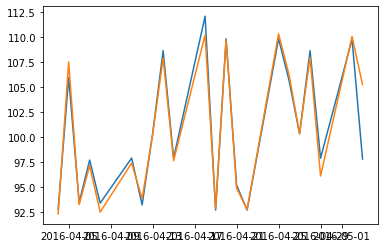

In [73]:
# sorry but we don't have time to transform this back to the normal unit. the accuracy looks good though.
plt.plot(stocks["Real"])
plt.plot(stocks["Predicted"])